# OI/Price Box Event Strategy Backtest Audit

이 노트북은 포트폴리오 제출용으로 정리한 OI/Price Box 전략 연구 노트북이다.  
핵심 흐름은 다음과 같다.

1. 가격 기반 추세추종의 한계를 시장 상태 구분 문제로 재정의한다.
2. Price Box와 Open Interest Box를 수식으로 정의한다.
3. 실제 거래소 데이터에서 박스와 이벤트 신호를 탐지한다.
4. dead-cat range, price box only, price + OI box 조건을 비교한다.
5. 거래비용, 손절, 포지션 사이징을 반영한 백테스트로 전략 품질을 점검한다.

> 원본 분석 노트북은 유지하고, 이 파일은 GitHub/포트폴리오 열람용으로 설명과 코드를 재배치한 버전이다.


## 0. Research Question

초기 접근은 가격 기반 추세추종이었다. 그러나 횡보장과 전환 구간에서는 신호가 자주 바뀌고, 수수료와 슬리피지가 누적되면서 손익비가 나빠지는 문제가 있었다.

따라서 문제를 다음처럼 재정의했다.

> 다음 방향을 맞히는 것보다, 지금 시장이 거래 가능한 상태인지 먼저 구분한다.

이를 위해 가격과 OI가 일정 범위 안에서 안정적으로 유지되는 구간을 `Box`로 정의하고, 박스의 유지·이탈·중심 이동을 시장 상태 변화의 단서로 사용한다.


In [1]:
from __future__ import annotations

from dataclasses import replace
from datetime import datetime, timedelta
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

# Notebook을 어느 위치에서 실행해도 프로젝트 루트를 찾도록 구성한다.
PROJECT_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'research').exists() and (candidate / 'apps').exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    PROJECT_ROOT = Path('/Users/changminkim/Desktop/projects/equidice/takora-trading')

DATA_ROOT = Path(os.environ.get('TAKORA_DATA_ROOT', '/Users/changminkim/Desktop/projects/equidice/datasets/exchange'))

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from research.microstructure_alpha.oi_box import (
    detect_oi_box_ranges,
    detect_stable_oi_box_ranges,
    diagnose_stable_oi_box_ranges,
    oi_boxes_to_frame,
)
from research.microstructure_alpha.box_event_signals import (
    BoxEventSignalConfig,
    detect_box_event_signals,
    plot_box_event_signals,
)
from research.microstructure_alpha.box_strategy_backtest import (
    BoxStrategyConfig,
    build_box_strategy_frame,
    candidate_box_strategy_configs,
    optimize_box_strategy,
)

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)
plt.style.use('default')

PROJECT_ROOT, DATA_ROOT, DATA_ROOT.exists()


(PosixPath('/Users/changminkim/Desktop/projects/equidice/takora-trading'),
 PosixPath('/Users/changminkim/Desktop/projects/equidice/datasets/exchange'),
 True)

## 1. Analysis Settings

이 노트북의 기본 검증 구간은 포트폴리오 본문에서 사용한 진단 구간과 맞춘다.

- 기간: `2026-05-22 00:00:00` ~ `2026-07-18 23:55:00`
- 봉 주기: `5m`
- 가격 데이터: Binance BTCUSDT futures trades 기반 OHLCV
- OI 데이터: Binance, Bitget, Bybit, OKX open interest를 USD value 기준으로 합산
- 비용 가정: fee 4bps, slippage 2bps, spread 1bps

데이터 경로가 다르면 `TAKORA_DATA_ROOT` 환경변수 또는 아래 `DATA_ROOT`를 수정한다.


In [3]:
START_TIME = '2026-05-22 00:00:00'
END_TIME = '2026-07-18 23:55:00'
BAR_SIZE = '5m'
EXCHANGES = ('binance', 'bitget', 'bybit', 'okx')

BASE_STRATEGY_CONFIG = BoxStrategyConfig(
    fee_bps=4.0,
    slippage_bps=2.0,
    spread_bps=1.0,
    max_leverage=0.7,
    max_holding_bars=288,
    risk_per_trade=0.0015,
    allow_short=True,
)

DATA_ROOT.exists()


True

## 2. Data Loading

전략 검증에 사용하는 데이터는 크게 두 종류다.

1. `Trades`: 실제 체결 데이터를 5분봉 OHLCV로 변환한다.
2. `Open Interest`: 거래소별 OI를 5분 단위로 정렬하고, 가능한 경우 USD value 기준으로 합산한다.

OI 값은 거래소마다 단위와 제공 필드가 다를 수 있으므로, `sum_open_interest_value`가 있으면 이를 우선 사용하고, 비어 있으면 `sum_open_interest × BTC price`로 근사한다.


In [4]:
def filter_paths_by_date(paths: list[Path], start_time: str, end_time: str) -> list[Path]:
    if not paths:
        return []
    start_dt = pd.to_datetime(start_time).date()
    end_dt = pd.to_datetime(end_time).date()
    target_dates = set()
    current = start_dt
    while current <= end_dt:
        target_dates.add(current.strftime('%Y-%m-%d'))
        target_dates.add(current.strftime('%Y%m%d'))
        current += timedelta(days=1)
    return [path for path in paths if any(date_string in path.name for date_string in target_dates)]


def timestamp_unit_for_parquet(path: Path) -> str:
    sample = pl.read_parquet(path, columns=['timestamp'], n_rows=1)
    value = int(sample['timestamp'][0])
    if value > 10**17:
        return 'ns'
    if value > 10**14:
        return 'us'
    if value > 10**11:
        return 'ms'
    return 's'


def load_exchange_ohlcv(
    trade_paths: list[Path],
    *,
    bar_size: str = BAR_SIZE,
    start_time: str = START_TIME,
    end_time: str = END_TIME,
) -> pd.DataFrame:
    trade_paths = filter_paths_by_date(trade_paths, start_time, end_time)
    if not trade_paths:
        return pd.DataFrame()

    lf = pl.scan_parquet([str(path) for path in trade_paths]).with_columns([
        pl.from_epoch(pl.col('trade_time'), time_unit='ms').alias('timestamp'),
        pl.col('price').cast(pl.Float64, strict=False).alias('price'),
        pl.col('quantity').cast(pl.Float64, strict=False).alias('quantity'),
    ])
    lf = lf.filter(pl.col('timestamp') >= datetime.fromisoformat(start_time))
    lf = lf.filter(pl.col('timestamp') <= datetime.fromisoformat(end_time))

    out = (
        lf.drop_nulls(['timestamp', 'price', 'quantity'])
        .filter((pl.col('price') > 0) & (pl.col('quantity') > 0))
        .sort('timestamp')
        .group_by_dynamic('timestamp', every=bar_size, period=bar_size)
        .agg([
            pl.col('price').first().alias('open'),
            pl.col('price').max().alias('high'),
            pl.col('price').min().alias('low'),
            pl.col('price').last().alias('close'),
            pl.col('quantity').sum().alias('volume'),
            pl.len().alias('trade_count'),
            pl.when(~pl.col('is_buyer_maker')).then(pl.col('quantity')).otherwise(0.0).sum().alias('taker_buy_volume'),
            pl.when(pl.col('is_buyer_maker')).then(pl.col('quantity')).otherwise(0.0).sum().alias('taker_sell_volume'),
        ])
        .collect()
        .to_pandas()
    )
    out['timestamp'] = pd.to_datetime(out['timestamp']).astype('datetime64[ns]')
    out = out.dropna(subset=['open', 'high', 'low', 'close']).sort_values('timestamp').reset_index(drop=True)
    out['taker_imbalance'] = (
        (out['taker_buy_volume'] - out['taker_sell_volume'])
        / (out['taker_buy_volume'] + out['taker_sell_volume']).replace(0, pd.NA)
    ).fillna(0.0)
    return out


def load_oi_value(
    exchange: str,
    paths: list[Path],
    price_df: pd.DataFrame,
    *,
    bar_size: str = BAR_SIZE,
    start_time: str = START_TIME,
    end_time: str = END_TIME,
) -> pd.DataFrame:
    paths = filter_paths_by_date(paths, start_time, end_time)
    if not paths:
        return pd.DataFrame()

    unit = timestamp_unit_for_parquet(paths[0])
    lf = pl.scan_parquet([str(path) for path in paths]).with_columns([
        pl.from_epoch(pl.col('timestamp'), time_unit=unit).alias('timestamp'),
        pl.col('sum_open_interest').cast(pl.Float64, strict=False).alias('amount'),
        pl.col('sum_open_interest_value').cast(pl.Float64, strict=False).alias('value'),
    ])
    lf = lf.filter(pl.col('timestamp') >= datetime.fromisoformat(start_time))
    lf = lf.filter(pl.col('timestamp') <= datetime.fromisoformat(end_time))

    out = (
        lf.sort('timestamp')
        .group_by_dynamic('timestamp', every=bar_size, period=bar_size)
        .agg([pl.col('amount').last(), pl.col('value').last()])
        .collect()
        .to_pandas()
    )
    if out.empty:
        return pd.DataFrame()

    out['timestamp'] = pd.to_datetime(out['timestamp']).astype('datetime64[ns]')
    out = out.sort_values('timestamp').drop_duplicates('timestamp')
    out = pd.merge_asof(
        out,
        price_df[['timestamp', 'close']].sort_values('timestamp'),
        on='timestamp',
        direction='backward',
    )
    out[f'oi_{exchange}'] = out['value'].where(
        out['value'].notna() & (out['value'] > 0),
        out['amount'] * out['close'],
    )
    return out[['timestamp', f'oi_{exchange}']].set_index('timestamp').sort_index()


In [5]:
trade_paths = sorted((DATA_ROOT / 'binance/assets/btcusdt/future/trades/hour').glob('*.parquet'))
price_df = load_exchange_ohlcv(trade_paths)

io_rows = []
oi_frames = []
for exchange in EXCHANGES:
    pattern = f'{exchange}/assets/btcusdt/future/openinterest/hour/*.parquet'
    paths = sorted(DATA_ROOT.glob(pattern))
    oi_part = load_oi_value(exchange, paths, price_df)
    io_rows.append({
        'dataset': f'{exchange}_openinterest',
        'files': len(filter_paths_by_date(paths, START_TIME, END_TIME)),
        'rows': len(oi_part),
    })
    if not oi_part.empty:
        oi_frames.append(oi_part)

if not oi_frames:
    raise RuntimeError('No OI data loaded. Check DATA_ROOT and exchange paths.')

oi_panel = pd.concat(oi_frames, axis=1).sort_index().ffill().dropna(how='all')
oi_panel['oi_total'] = oi_panel.sum(axis=1, min_count=2)
oi_df = oi_panel[['oi_total']].dropna().reset_index()
oi_df['timestamp'] = pd.to_datetime(oi_df['timestamp']).astype('datetime64[ns]')

common_start = max(price_df['timestamp'].min(), oi_df['timestamp'].min())
common_end = min(price_df['timestamp'].max(), oi_df['timestamp'].max())
price_df = price_df[(price_df['timestamp'] >= common_start) & (price_df['timestamp'] <= common_end)].reset_index(drop=True)
oi_df = oi_df[(oi_df['timestamp'] >= common_start) & (oi_df['timestamp'] <= common_end)].reset_index(drop=True)

load_summary = pd.DataFrame(io_rows)
load_summary.loc[len(load_summary)] = {
    'dataset': 'binance_trades_price',
    'files': len(filter_paths_by_date(trade_paths, START_TIME, END_TIME)),
    'rows': len(price_df),
}

display(load_summary)
display(pd.DataFrame([{
    'common_start': common_start,
    'common_end': common_end,
    'price_rows': len(price_df),
    'oi_rows': len(oi_df),
    'bar_size': BAR_SIZE,
}]))


,dataset,files,rows
0,binance_openinterest,1392,16704
1,bitget_openinterest,1392,16697
2,bybit_openinterest,1392,16703
3,okx_openinterest,1392,16703
4,binance_trades_price,1392,16703


,common_start,common_end,price_rows,oi_rows,bar_size
0,2026-05-22,2026-07-18 23:50:00,16703,16703,5m


## 3. Box Detection Formula & Implementation

### 3.1 Overview

박스권 탐지의 핵심 질문은 다음과 같다.

> 일정 기간 동안 값이 중심값 근처에 안정적으로 머무는가?

가격 또는 OI가 일정 시간 동안 특정 범위 안에서 안정적으로 움직이면 박스권으로 보고, 그 범위를 지속적으로 이탈하거나 중심값이 크게 이동하면 기존 박스가 끝났다고 판단한다.

입력값은 가격 박스와 OI 박스 모두 같은 구조로 표현할 수 있다.

$$
x_t = Price_t \quad \text{or} \quad x_t = OI_t
$$

중심값:

$$
m_t = \mathrm{median}(x_{t-w:t})
$$

박스 상단/하단:

$$
Upper_t = Q_{high}(x_{t-w:t}), \qquad Lower_t = Q_{low}(x_{t-w:t})
$$

박스 폭 비율:

$$
WidthRatio_t = \frac{Upper_t - Lower_t}{m_t}
$$

박스 폭이 작으면 안정적인 구간으로 해석하고, 박스 폭이 너무 크면 단순 변동성 확대 구간으로 보고 제외한다.


### 3.2 Code Reference

| Concept | Source |
|---|---|
| 후보 구간 생성 | `oi_box.py`, `detect_oi_box_ranges`, `current_values = values[start_idx:idx]` |
| 분위수 기반 bounds | `oi_box.py`, `_robust_bounds`, `np.nanquantile(...)` |
| margin / min width | `oi_box.py`, `_robust_bounds` |
| 내부 여부 판단 | `oi_box.py`, `_summarize_box`, `inside = (values >= low) & (values <= high)` |
| 지속 이탈 확인 | `oi_box.py`, `outside_count >= breakout_confirm_bars` |
| 중심 이동 감지 | `oi_box.py`, `center_gap = abs(median(recent) - median(stable))` |
| 품질 점수 | `oi_box.py`, `score = 0.55 * coverage + 0.30 * touch + 0.15 * duration` |
| Stable Box | `oi_box.py`, `detect_stable_oi_box_ranges` |


In [ ]:
def toy_box_series(seed: int = 7) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    stable = 1000 + rng.normal(0, 5, 90)
    shifted = 1030 + rng.normal(0, 5, 35)
    values = np.r_[stable, shifted]
    values[55] = 1060  # one temporary spike
    ts = pd.date_range('2026-06-01', periods=len(values), freq='5min')
    return pd.DataFrame({'timestamp': ts, 'value': values})


def robust_bounds(values, q_low=0.10, q_high=0.90, margin=0.08, min_width_ratio=0.001):
    ql, qh = np.nanquantile(values, [q_low, q_high])
    min_width = np.nanmedian(values) * min_width_ratio
    width = max(qh - ql, min_width)
    lower = ql - margin * width
    upper = qh + margin * width
    return ql, qh, lower, upper, width, min_width


toy_df = toy_box_series()
toy_df.head()


,timestamp,value
0,2026-06-01 00:00:00,1000.006151
1,2026-06-01 00:05:00,1001.493728
2,2026-06-01 00:10:00,998.629311
3,2026-06-01 00:15:00,995.547041
4,2026-06-01 00:20:00,997.726646


### 3.3 박스 후보 구간

특정 시작점부터 현재 시점까지의 값을 계속 보면서 박스 범위를 계산한다.

$$
W_t = \{x_s, x_{s+1}, \dots, x_t\}
$$

- $s$: 박스 시작 후보 시점
- $t$: 현재 시점
- $W_t$: 현재까지의 관찰 구간

```text
시간 →
s                                           t
|-------------------------------------------|
          현재 박스 후보 관찰 구간 W_t
```

구현상으로는 `start_idx`부터 `idx` 직전까지의 값을 `current_values`로 두고, 이 구간의 분위수와 margin으로 박스 후보를 갱신한다.


In [7]:
example_start_idx = 0
example_idx = 90
current_values = toy_df['value'].to_numpy()[example_start_idx:example_idx]

pd.DataFrame([{
    'start_idx': example_start_idx,
    'idx': example_idx,
    'bars': len(current_values),
    'start_time': toy_df['timestamp'].iloc[example_start_idx],
    'end_time': toy_df['timestamp'].iloc[example_idx - 1],
    'median': np.median(current_values),
}])


,start_idx,idx,bars,start_time,end_time,median
0,0,90,90,2026-06-01,2026-06-01 07:25:00,999.230747


### 3.4 평균이 아니라 분위수를 쓰는 이유

박스 상단/하단을 단순 최댓값·최솟값으로 잡으면 이상치 하나에 너무 흔들린다. 예를 들어 OI가 대부분 1,000 근처인데 한 번 1,060으로 튀면, 최댓값 기준 박스 상단이 과도하게 높아진다.

따라서 상단/하단은 평균이나 최댓값·최솟값이 아니라 분위수를 기준으로 잡는다.

$$
Q_{low,t} = Quantile(W_t, q_{low})
$$

$$
Q_{high,t} = Quantile(W_t, q_{high})
$$

기본값은 다음과 같다.

$$
q_{low}=0.10, \qquad q_{high}=0.90
$$

즉, 하위 10%와 상위 10% 꼬리를 일부 제외하고, 대부분의 값이 머무는 중앙 80% 분포를 박스의 본체로 본다.


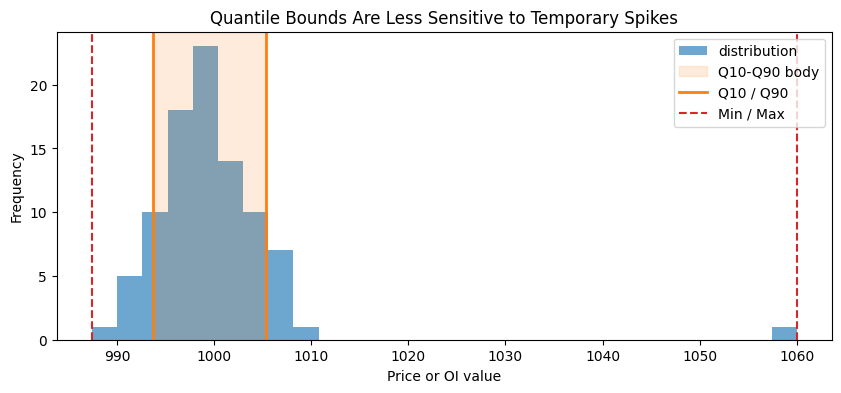

,min,max,min_max_width,q10,q90,q10_q90_width
0,987.416201,1060.0,72.583799,993.651722,1005.346655,11.694933


In [8]:
values = toy_df.iloc[:90]['value'].to_numpy()
q10, q90 = np.nanquantile(values, [0.10, 0.90])
vmin, vmax = np.nanmin(values), np.nanmax(values)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(values, bins=28, alpha=0.65, color='tab:blue', label='distribution')
ax.axvspan(q10, q90, color='tab:orange', alpha=0.15, label='Q10-Q90 body')
ax.axvline(q10, color='tab:orange', linewidth=2, label='Q10 / Q90')
ax.axvline(q90, color='tab:orange', linewidth=2)
ax.axvline(vmin, color='tab:red', linestyle='--', linewidth=1.5, label='Min / Max')
ax.axvline(vmax, color='tab:red', linestyle='--', linewidth=1.5)
ax.set_title('Quantile Bounds Are Less Sensitive to Temporary Spikes')
ax.set_xlabel('Price or OI value')
ax.set_ylabel('Frequency')
ax.legend(loc='upper right')
plt.show()

pd.DataFrame([{
    'min': vmin,
    'max': vmax,
    'min_max_width': vmax - vmin,
    'q10': q10,
    'q90': q90,
    'q10_q90_width': q90 - q10,
}])


### 3.5 박스 상단/하단 계산

먼저 기본 폭을 계산한다.

$$
Width_{raw,t} = Q_{high,t} - Q_{low,t}
$$

값이 거의 움직이지 않으면 폭이 0에 가까워질 수 있으므로 최소 폭을 둔다.

$$
Width_t = \max(Q_{high,t} - Q_{low,t},\ Width_{min})
$$

$$
Width_{min} = Median(x) \times min\_width\_ratio
$$

그 다음 정상적인 흔들림을 받아주기 위해 margin을 붙인다.

$$
Lower_t = Q_{low,t} - margin \times Width_t
$$

$$
Upper_t = Q_{high,t} + margin \times Width_t
$$

중심값과 최종 박스 폭은 다음과 같다.

$$
Mid_t = \frac{Upper_t + Lower_t}{2}
$$

$$
BoxWidth_t = Upper_t - Lower_t
$$

`margin_ratio=0.08`이면 Q10-Q90 본체 폭의 8%를 위아래에 붙인다. 폭이 100이면 위아래 8씩 추가되어 전체 박스는 16만큼 넓어진다.


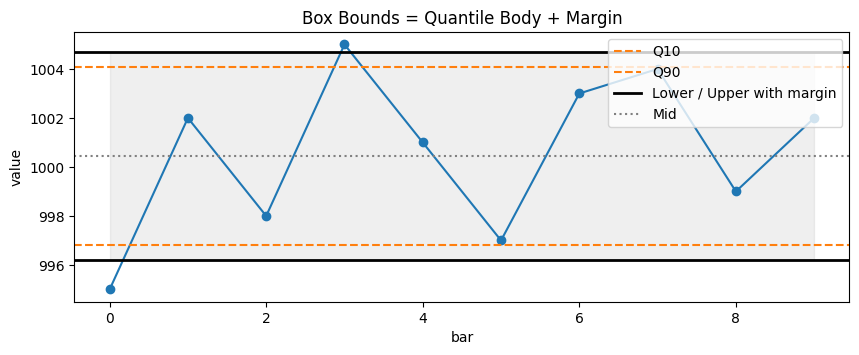

,q10,q90,raw_width,min_width,width,lower,upper,mid,box_width
0,996.8,1004.1,7.3,1.0015,7.3,996.216,1004.684,1000.45,8.468


In [9]:
example_values = np.array([995, 1002, 998, 1005, 1001, 997, 1003, 1004, 999, 1002], dtype=float)
q10, q90, lower, upper, width, min_width = robust_bounds(example_values, margin=0.08)
mid = (lower + upper) / 2.0

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(range(len(example_values)), example_values, marker='o', color='tab:blue')
ax.axhline(q10, color='tab:orange', linestyle='--', label='Q10')
ax.axhline(q90, color='tab:orange', linestyle='--', label='Q90')
ax.axhline(lower, color='black', linewidth=2, label='Lower / Upper with margin')
ax.axhline(upper, color='black', linewidth=2)
ax.axhline(mid, color='gray', linestyle=':', label='Mid')
ax.fill_between(range(len(example_values)), lower, upper, color='gray', alpha=0.12)
ax.set_title('Box Bounds = Quantile Body + Margin')
ax.set_xlabel('bar')
ax.set_ylabel('value')
ax.legend(loc='upper right')
plt.show()

pd.DataFrame([{
    'q10': q10,
    'q90': q90,
    'raw_width': q90 - q10,
    'min_width': min_width,
    'width': width,
    'lower': lower,
    'upper': upper,
    'mid': mid,
    'box_width': upper - lower,
}])


### 3.6 박스 안에 있는지 판단 및 지속 이탈 확인

각 시점의 값이 박스 안에 있으면 다음 조건을 만족한다.

$$
Lower_t \leq x_t \leq Upper_t
$$

박스 밖으로 나간 경우는 다음과 같다.

$$
x_t > Upper_t \quad \text{or} \quad x_t < Lower_t
$$

다만 한 번 튄 값을 바로 박스 이탈로 보지는 않는다. 금융 시계열에는 일시적인 spike가 자주 발생하기 때문에, 이탈이 진짜인지 buffer와 지속 시간으로 확인한다.

$$
Buffer_t = \max(BoxWidth_t \times breakout\_buffer\_ratio,\ Width_{min})
$$

상방 이탈 후보:

$$
x_t > Upper_t + Buffer_t
$$

하방 이탈 후보:

$$
x_t < Lower_t - Buffer_t
$$

이후 같은 방향으로 $k$개 봉 이상 지속될 때만 이탈을 확정한다.

$$
x_t, x_{t+1}, \dots, x_{t+k-1} > Upper_t + Buffer_t
$$

$$
x_t, x_{t+1}, \dots, x_{t+k-1} < Lower_t - Buffer_t
$$

기본값은 `breakout_confirm_bars=6`이며, 5분봉 기준 약 30분이다.


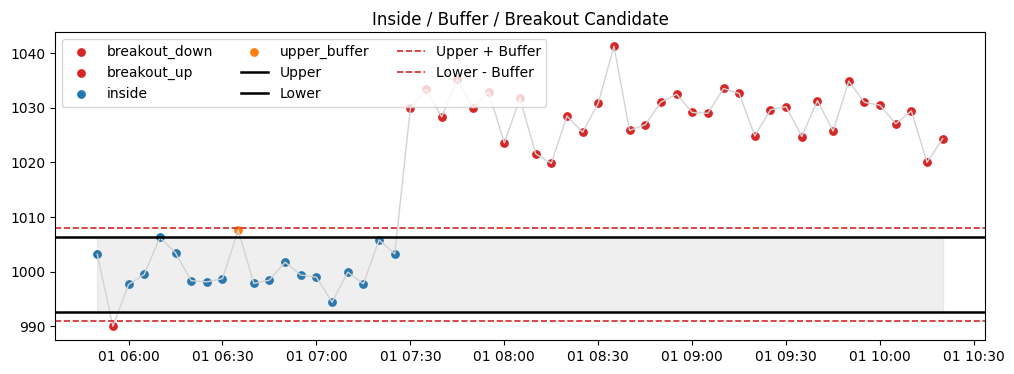

,timestamp,value,zone
113,2026-06-01 09:25:00,1029.604093,breakout_up
114,2026-06-01 09:30:00,1030.176434,breakout_up
115,2026-06-01 09:35:00,1024.727577,breakout_up
116,2026-06-01 09:40:00,1031.299196,breakout_up
117,2026-06-01 09:45:00,1025.710218,breakout_up
118,2026-06-01 09:50:00,1034.860334,breakout_up
119,2026-06-01 09:55:00,1030.963730,breakout_up
120,2026-06-01 10:00:00,1030.446532,breakout_up
121,2026-06-01 10:05:00,1027.044858,breakout_up
122,2026-06-01 10:10:00,1029.406951,breakout_up


In [10]:
base_values = toy_df.iloc[:80]['value'].to_numpy()
q10, q90, lower, upper, width, min_width = robust_bounds(base_values)
buffer = max((upper - lower) * 0.12, min_width)

future = toy_df.iloc[70:125].copy()
future['zone'] = 'inside'
future.loc[(future['value'] > upper) & (future['value'] <= upper + buffer), 'zone'] = 'upper_buffer'
future.loc[(future['value'] < lower) & (future['value'] >= lower - buffer), 'zone'] = 'lower_buffer'
future.loc[future['value'] > upper + buffer, 'zone'] = 'breakout_up'
future.loc[future['value'] < lower - buffer, 'zone'] = 'breakout_down'

colors = {
    'inside': 'tab:blue',
    'upper_buffer': 'tab:orange',
    'lower_buffer': 'tab:orange',
    'breakout_up': 'tab:red',
    'breakout_down': 'tab:red',
}

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(future['timestamp'], future['value'], color='lightgray', linewidth=1.0)
for zone, part in future.groupby('zone'):
    ax.scatter(part['timestamp'], part['value'], s=28, color=colors[zone], label=zone)
ax.axhline(upper, color='black', linewidth=1.8, label='Upper')
ax.axhline(lower, color='black', linewidth=1.8, label='Lower')
ax.axhline(upper + buffer, color='tab:red', linestyle='--', linewidth=1.2, label='Upper + Buffer')
ax.axhline(lower - buffer, color='tab:red', linestyle='--', linewidth=1.2, label='Lower - Buffer')
ax.fill_between(future['timestamp'], lower, upper, color='gray', alpha=0.12)
ax.set_title('Inside / Buffer / Breakout Candidate')
ax.legend(loc='upper left', ncol=3)
plt.show()

future[['timestamp', 'value', 'zone']].tail(12)


### 3.7 중심 이동 감지

박스는 반드시 상단/하단을 강하게 이탈하면서 끝나는 것은 아니다. 값이 기존 박스 근처에 있으면서도, 최근 값들의 중심이 이전보다 위나 아래로 이동해 새로운 레벨에서 안정화되는 경우가 있다.

과거 안정 구간과 최근 구간을 나눈다.

$$
W_{stable}, \qquad W_{recent}
$$

각각의 중심값은 median으로 계산한다.

$$
M_{stable} = Median(W_{stable})
$$

$$
M_{recent} = Median(W_{recent})
$$

중심 이동 폭은 다음과 같다.

$$
CenterGap = |M_{recent} - M_{stable}|
$$

이 값이 기존 박스 폭 대비 충분히 크면 중심 이동으로 판단한다.

$$
CenterGap > \max(StableWidth \times center\_shift\_ratio,\ Width_{min})
$$

`center_shift_ratio=0.90`이면 기존 박스 폭의 90% 이상 중심이 이동할 때 새 박스로 판단한다.


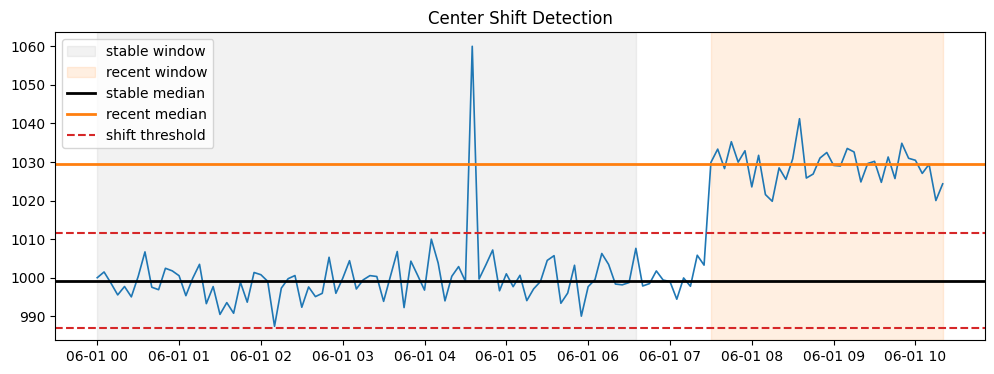

,M_stable,M_recent,CenterGap,Threshold,center_shift_detected
0,999.253418,1029.604093,30.350676,12.331037,True


In [11]:
stable_values = toy_df.iloc[:80]['value'].to_numpy()
recent_values = toy_df.iloc[90:125]['value'].to_numpy()
q10, q90, lower, upper, width, min_width = robust_bounds(stable_values)

m_stable = np.nanmedian(stable_values)
m_recent = np.nanmedian(recent_values)
stable_width = upper - lower
center_gap = abs(m_recent - m_stable)
threshold = max(stable_width * 0.90, min_width)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(toy_df['timestamp'], toy_df['value'], color='tab:blue', linewidth=1.2)
ax.axvspan(toy_df['timestamp'].iloc[0], toy_df['timestamp'].iloc[79], color='gray', alpha=0.10, label='stable window')
ax.axvspan(toy_df['timestamp'].iloc[90], toy_df['timestamp'].iloc[-1], color='tab:orange', alpha=0.12, label='recent window')
ax.axhline(m_stable, color='black', linewidth=2, label='stable median')
ax.axhline(m_recent, color='tab:orange', linewidth=2, label='recent median')
ax.axhline(m_stable + threshold, color='tab:red', linestyle='--', label='shift threshold')
ax.axhline(m_stable - threshold, color='tab:red', linestyle='--')
ax.set_title('Center Shift Detection')
ax.legend(loc='upper left')
plt.show()

pd.DataFrame([{
    'M_stable': m_stable,
    'M_recent': m_recent,
    'CenterGap': center_gap,
    'Threshold': threshold,
    'center_shift_detected': center_gap > threshold,
}])


### 3.8 박스 품질 점수

탐지된 박스가 모두 같은 품질이라고 보지는 않는다. 박스 품질은 다음 세 가지로 점수화한다.

1. 박스 안에 얼마나 많이 있었는가
2. 상단/하단을 얼마나 자주 터치했는가
3. 박스가 충분히 오래 지속됐는가

Coverage:

$$
Coverage = \frac{\#\{Lower \leq x_i \leq Upper\}}{N}
$$

TouchScore:

$$
TouchScore =
\min\left(
1,
\frac{LowTouches + HighTouches}{\max(2,\ 0.08N)}
\right)
$$

하단 근처 터치:

$$
x_i \leq Lower + touch\_band
$$

상단 근처 터치:

$$
x_i \geq Upper - touch\_band
$$

터치 구간 폭:

$$
touch\_band = \max(width \times touch\_ratio,\ min\_width)
$$

DurationScore:

$$
DurationScore = \min\left(1,\ \frac{N}{96}\right)
$$

최종 점수:

$$
Score = 0.55 \times Coverage + 0.30 \times TouchScore + 0.15 \times DurationScore
$$

Coverage에 가장 큰 비중을 둔 이유는 박스의 기본 조건이 안정적인 범위 유지라고 봤기 때문이다.


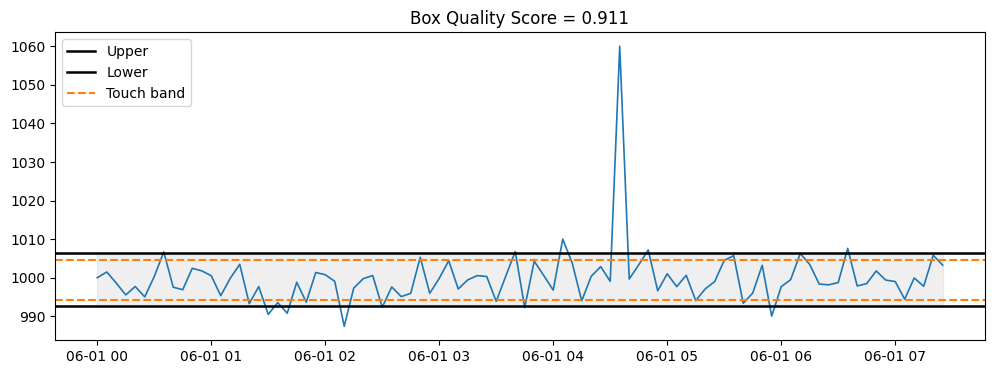

,coverage,low_touches,high_touches,touch_score,duration_score,score
0,0.855556,13,10,1.0,0.9375,0.911181


In [12]:
sample = toy_df.iloc[:90].copy()
q10, q90, lower, upper, width, min_width = robust_bounds(sample['value'].to_numpy())
box_width = upper - lower
touch_band = max(box_width * 0.12, min_width)

values = sample['value'].to_numpy()
inside = (values >= lower) & (values <= upper)
low_touches = int(np.sum(values <= lower + touch_band))
high_touches = int(np.sum(values >= upper - touch_band))
coverage = float(np.mean(inside))
touch_score = min(1.0, (low_touches + high_touches) / max(2.0, len(values) * 0.08))
duration_score = min(1.0, len(values) / 96.0)
score = 0.55 * coverage + 0.30 * touch_score + 0.15 * duration_score

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sample['timestamp'], sample['value'], color='tab:blue', linewidth=1.2)
ax.axhline(upper, color='black', linewidth=1.8, label='Upper')
ax.axhline(lower, color='black', linewidth=1.8, label='Lower')
ax.axhline(upper - touch_band, color='tab:orange', linestyle='--', label='Touch band')
ax.axhline(lower + touch_band, color='tab:orange', linestyle='--')
ax.fill_between(sample['timestamp'], lower, upper, color='gray', alpha=0.12)
ax.set_title(f'Box Quality Score = {score:.3f}')
ax.legend(loc='upper left')
plt.show()

pd.DataFrame([{
    'coverage': coverage,
    'low_touches': low_touches,
    'high_touches': high_touches,
    'touch_score': touch_score,
    'duration_score': duration_score,
    'score': score,
}])


### 3.9 Stable Box 개선

기본 박스 탐지는 시작 시점에 따라 결과가 달라질 수 있다. 이는 박스 탐지가 시작점부터 누적해서 범위를 만들기 때문에 발생하는 path-dependency다.

Stable Box는 여러 시작점에서 박스를 각각 탐지한 뒤, 반복적으로 나타나는 박스만 채택한다.

$$
Run_1, Run_2, \dots, Run_n
$$

각 run에서 나온 후보 박스들은 다음 기준으로 비교한다.

레벨 유사성:

$$
Mid_i = \frac{High_i + Low_i}{2}
$$

$$
|Mid_i - Mid_j| \leq LevelTolerance
$$

시간 겹침:

$$
OverlapRatio =
\frac{Duration(Box_i \cap Box_j)}
{\min(Duration(Box_i), Duration(Box_j))}
$$

$$
OverlapRatio \geq \theta_{overlap}
$$

반복 검출 여부:

$$
Support = \#\{distinct\ start\ runs\}
$$

$$
Support \geq RequiredSupport
$$

최종 Stable Box의 상단/하단과 시작/끝은 후보 박스들의 median으로 계산한다.

$$
Low_{stable} = Median(Low_1, Low_2, \dots, Low_n)
$$

$$
High_{stable} = Median(High_1, High_2, \dots, High_n)
$$

$$
Start_{stable} = Median(Start_1, Start_2, \dots, Start_n)
$$

$$
End_{stable} = Median(End_1, End_2, \dots, End_n)
$$


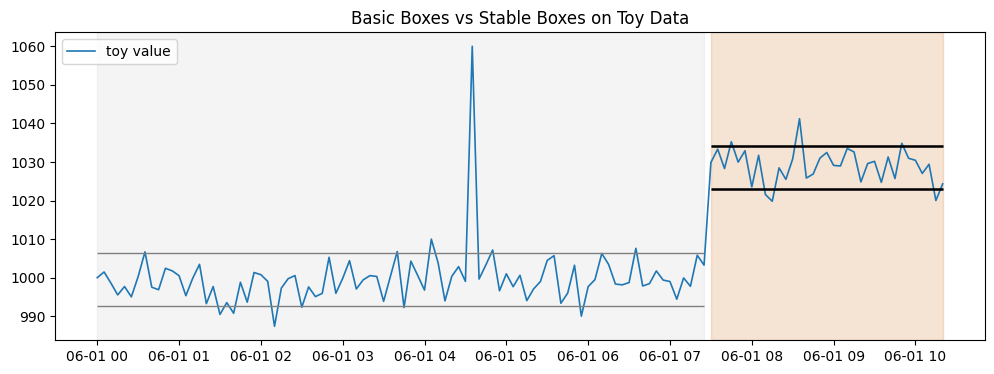

,type,count
0,raw_box,2
1,stable_box,1


In [13]:
# Toy data에서도 basic box와 stable box를 비교한다.
toy_raw_boxes = detect_oi_box_ranges(
    toy_df,
    timestamp_col='timestamp',
    value_col='value',
    min_bars=24,
    center_shift_bars=12,
    center_shift_ratio=0.90,
    breakout_confirm_bars=3,
)

toy_stable_boxes = detect_stable_oi_box_ranges(
    toy_df,
    timestamp_col='timestamp',
    value_col='value',
    min_bars=24,
    center_shift_bars=12,
    center_shift_ratio=0.90,
    breakout_confirm_bars=3,
    start_step_bars=6,
    warmup_bars=12,
    max_box_width_ratio=0.08,
    min_consensus_starts=2,
    min_consensus_ratio=0.25,
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(toy_df['timestamp'], toy_df['value'], color='tab:blue', linewidth=1.2, label='toy value')
for box in toy_raw_boxes:
    ax.axvspan(box.start, box.end, color='tab:gray', alpha=0.08)
    ax.hlines([box.low, box.high], box.start, box.end, color='tab:gray', linewidth=1.0)
for box in toy_stable_boxes:
    ax.axvspan(box.start, box.end, color='tab:orange', alpha=0.14)
    ax.hlines([box.low, box.high], box.start, box.end, color='black', linewidth=1.8)
ax.set_title('Basic Boxes vs Stable Boxes on Toy Data')
ax.legend(loc='upper left')
plt.show()

pd.DataFrame([
    {'type': 'raw_box', 'count': len(toy_raw_boxes)},
    {'type': 'stable_box', 'count': len(toy_stable_boxes)},
])


## 4. Detect Price / OI Boxes On Real Data

이제 위 수식을 실제 데이터에 적용한다.

- `stable_oi_boxes`: 여러 시작점에서 반복적으로 탐지된 OI 박스
- `price_boxes`: 가격 기준 박스

전략에서는 `Price Box`를 거래 range의 기준으로 사용하고, `Stable OI Box`는 해당 range가 시장 참여자 포지션 구조와 함께 유지되는지 확인하는 필터로 사용한다.


In [14]:
BOX_KWARGS = dict(
    min_bars=72,
    lower_quantile=0.10,
    upper_quantile=0.90,
    margin_ratio=0.08,
    breakout_buffer_ratio=0.12,
    center_shift_bars=48,
    center_shift_ratio=0.90,
    breakout_confirm_bars=6,
    min_width_ratio=0.001,
    touch_ratio=0.12,
)

stable_oi_boxes = detect_stable_oi_box_ranges(
    oi_df,
    timestamp_col='timestamp',
    value_col='oi_total',
    **BOX_KWARGS,
    start_step_bars=12,
    warmup_bars=72,
    max_box_width_ratio=0.035,
    min_consensus_starts=2,
    min_consensus_ratio=0.30,
    level_tolerance_ratio=0.006,
    time_overlap_ratio=0.35,
)

price_boxes = detect_oi_box_ranges(
    price_df,
    timestamp_col='timestamp',
    value_col='close',
    **BOX_KWARGS,
)

box_diagnostics = diagnose_stable_oi_box_ranges(
    oi_df,
    timestamp_col='timestamp',
    value_col='oi_total',
    **BOX_KWARGS,
    start_step_bars=12,
    warmup_bars=72,
    max_box_width_ratio=0.035,
    min_consensus_starts=2,
    min_consensus_ratio=0.30,
    level_tolerance_ratio=0.006,
    time_overlap_ratio=0.35,
)

box_summary = pd.DataFrame([
    {'box_type': 'stable_oi_box', 'count': len(stable_oi_boxes)},
    {'box_type': 'price_box', 'count': len(price_boxes)},
])
display(box_summary)
display(pd.DataFrame([box_diagnostics.to_dict()]))
display(oi_boxes_to_frame(stable_oi_boxes).head(10) if stable_oi_boxes else pd.DataFrame())
display(oi_boxes_to_frame(price_boxes).head(10) if price_boxes else pd.DataFrame())


,box_type,count
0,stable_oi_box,95
1,price_box,96


,start_offsets,raw_boxes,after_warmup_boxes,after_width_boxes,rejected_by_warmup,rejected_by_width,clusters,required_support,stable_clusters,stable_boxes,max_raw_width_ratio,max_candidate_width_ratio,cluster_supports
0,"(0, 12, 24, 36, 48, 60, 72, 84, 96, 108, 120)",1096,1085,1052,11,33,95,4,95,95,0.0535,0.032104,"(11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 1..."


,box_id,start,end,low,high,mid,width,bars,coverage,low_touches,high_touches,break_direction,score
0,0,2026-05-22 14:40:00,2026-05-24 13:45:00,1.677130e+10,1.718672e+10,1.697901e+10,4.154241e+08,566,0.890459,86,83,down,0.935811
1,1,2026-05-24 13:55:00,2026-05-24 21:25:00,1.647700e+10,1.654210e+10,1.650955e+10,6.510359e+07,91,0.901099,29,16,down,0.950649
2,2,2026-05-24 21:30:00,2026-05-25 04:35:00,1.636591e+10,1.647116e+10,1.641853e+10,1.052487e+08,86,0.848837,11,22,up,0.920887
3,3,2026-05-25 04:40:00,2026-05-25 14:35:00,1.667821e+10,1.684405e+10,1.676113e+10,1.658467e+08,120,0.875000,16,21,up,0.947500
4,4,2026-05-25 14:40:00,2026-05-25 20:35:00,1.682334e+10,1.691542e+10,1.686938e+10,9.207676e+07,72,0.930556,13,20,down,0.933333
5,5,2026-05-25 20:40:00,2026-05-26 14:50:00,1.629451e+10,1.677812e+10,1.653632e+10,4.836156e+08,219,0.904110,26,38,down,0.959726
6,6,2026-05-26 14:55:00,2026-05-27 00:45:00,1.613445e+10,1.622256e+10,1.617851e+10,8.810732e+07,119,0.857143,15,18,up,0.940000
7,7,2026-05-27 00:50:00,2026-05-27 06:45:00,1.623234e+10,1.660167e+10,1.641701e+10,3.693241e+08,72,0.930556,23,10,center_shift,0.933333
8,8,2026-05-27 06:50:00,2026-05-27 13:40:00,1.666407e+10,1.682160e+10,1.674284e+10,1.575352e+08,83,0.855422,10,19,up,0.918965
9,9,2026-05-27 13:45:00,2026-05-27 21:35:00,1.689765e+10,1.712934e+10,1.701350e+10,2.316836e+08,95,0.905263,15,14,down,0.958648


,box_id,start,end,low,high,mid,width,bars,coverage,low_touches,high_touches,break_direction,score
0,0,2026-05-22 00:00:00,2026-05-22 13:55:00,77228.1016,77712.0884,77470.095,483.9868,168,0.839286,34,24,down,0.911607
1,1,2026-05-22 14:00:00,2026-05-22 19:55:00,76154.5960,76998.2640,76576.430,843.6680,72,0.861111,9,15,center_shift,0.886111
2,2,2026-05-22 20:00:00,2026-05-23 07:40:00,75316.7320,75986.1680,75651.450,669.4360,141,0.886525,21,18,down,0.937589
3,3,2026-05-23 07:45:00,2026-05-23 13:40:00,74554.7100,74933.7400,74744.225,379.0300,72,0.902778,10,10,up,0.909028
4,4,2026-05-23 13:45:00,2026-05-23 20:25:00,75244.5360,75973.3640,75608.950,728.8280,81,0.876543,9,13,up,0.908661
5,5,2026-05-23 20:30:00,2026-05-24 10:20:00,76618.5424,76962.7376,76790.640,344.1952,167,0.874251,30,24,up,0.930838
6,6,2026-05-24 10:25:00,2026-05-25 14:40:00,76485.5328,77496.2872,76990.910,1010.7544,340,0.855882,46,59,up,0.920735
7,7,2026-05-25 14:45:00,2026-05-26 00:10:00,77196.6444,77685.9556,77441.300,489.3112,114,0.885965,19,17,down,0.937281
8,8,2026-05-26 00:15:00,2026-05-26 10:20:00,76591.3976,76900.8624,76746.130,309.4648,122,0.860656,44,22,up,0.923361
9,9,2026-05-26 10:25:00,2026-05-26 17:15:00,76360.5432,77473.5168,76917.030,1112.9736,83,0.903614,13,11,down,0.926675


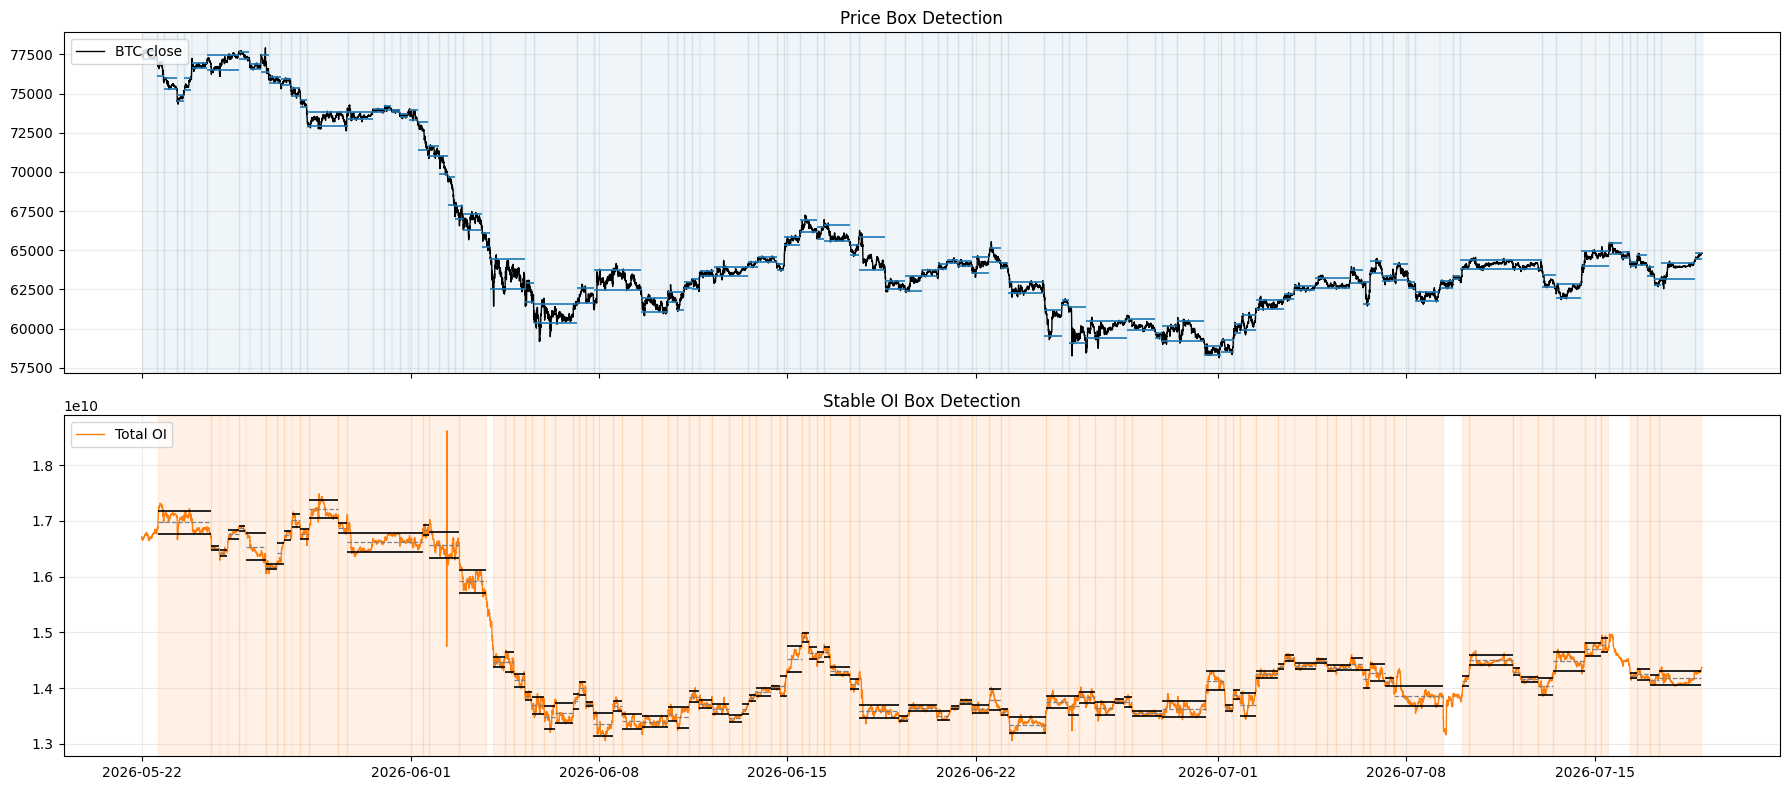

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)

axes[0].plot(price_df['timestamp'], price_df['close'], color='black', linewidth=1.0, label='BTC close')
for box in price_boxes:
    axes[0].axvspan(box.start, box.end, color='tab:blue', alpha=0.07)
    axes[0].hlines([box.low, box.high], box.start, box.end, color='tab:blue', linewidth=1.2)
axes[0].set_title('Price Box Detection')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.25)

axes[1].plot(oi_df['timestamp'], oi_df['oi_total'], color='tab:orange', linewidth=1.0, label='Total OI')
for box in stable_oi_boxes:
    axes[1].axvspan(box.start, box.end, color='tab:orange', alpha=0.10)
    axes[1].hlines([box.low, box.high], box.start, box.end, color='black', linewidth=1.2)
    axes[1].hlines(box.mid, box.start, box.end, color='gray', linestyle='--', linewidth=0.9)
axes[1].set_title('Stable OI Box Detection')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


## 5. Box Event Signal Layer

박스 탐지 이후에는 세 가지 이벤트 레이어를 추가한다.

1. `terminal_oi_volatility`: 박스 종료 부근에서 OI 변동성이 커지는지 확인한다.
2. `transient_oi_shocks`: OI shock이 금방 되돌아오는 일시적 충격인지, 유지되는 persistent shock인지 구분한다.
3. `deadcat_bounce_ranges`: 큰 낙폭 이후 반등 상단/하단을 진단용 레벨로 관찰한다.

최종 전략에서는 dead-cat range를 직접 진입 range로 쓰지 않고, 진단 및 ablation 비교 대상으로만 사용한다.


In [16]:
event_config = BoxEventSignalConfig(
    terminal_lookback_bars=144,
    terminal_bars=36,
    terminal_range_ratio=1.6,
    terminal_net_change_z=3.0,
    shock_baseline_bars=288,
    shock_window_bars=12,
    shock_reversion_bars=144,
    shock_z=5.0,
    shock_min_change_ratio=0.006,
    shock_max_reversion_fraction=0.35,
    trough_search_bars=72,
    rebound_bars=1440,
    drop_threshold_bps=350.0,
    min_rebound_bps=80.0,
)

box_event_signals = detect_box_event_signals(
    oi_frame=oi_df,
    price_frame=price_df,
    oi_boxes=stable_oi_boxes,
    price_boxes=price_boxes,
    timestamp_col='timestamp',
    oi_col='oi_total',
    price_col='close',
    high_col='high',
    low_col='low',
    config=event_config,
)

terminal_oi_volatility = box_event_signals['terminal_oi_volatility']
transient_oi_shocks = box_event_signals['transient_oi_shocks']
deadcat_bounce_ranges = box_event_signals['deadcat_bounce_ranges']

event_summary = pd.DataFrame([
    {'signal': 'terminal_oi_volatility', 'rows': len(terminal_oi_volatility), 'active': int(terminal_oi_volatility.get('is_terminal_oi_expansion', pd.Series(dtype=bool)).sum())},
    {'signal': 'transient_oi_shocks', 'rows': len(transient_oi_shocks), 'active': int(transient_oi_shocks.get('is_transient', pd.Series(dtype=bool)).sum())},
    {'signal': 'deadcat_bounce_ranges', 'rows': len(deadcat_bounce_ranges), 'active': int(deadcat_bounce_ranges.get('is_deadcat_range', pd.Series(dtype=bool)).sum())},
])

display(event_summary)


,signal,rows,active
0,terminal_oi_volatility,28,23
1,transient_oi_shocks,24,14
2,deadcat_bounce_ranges,19,19


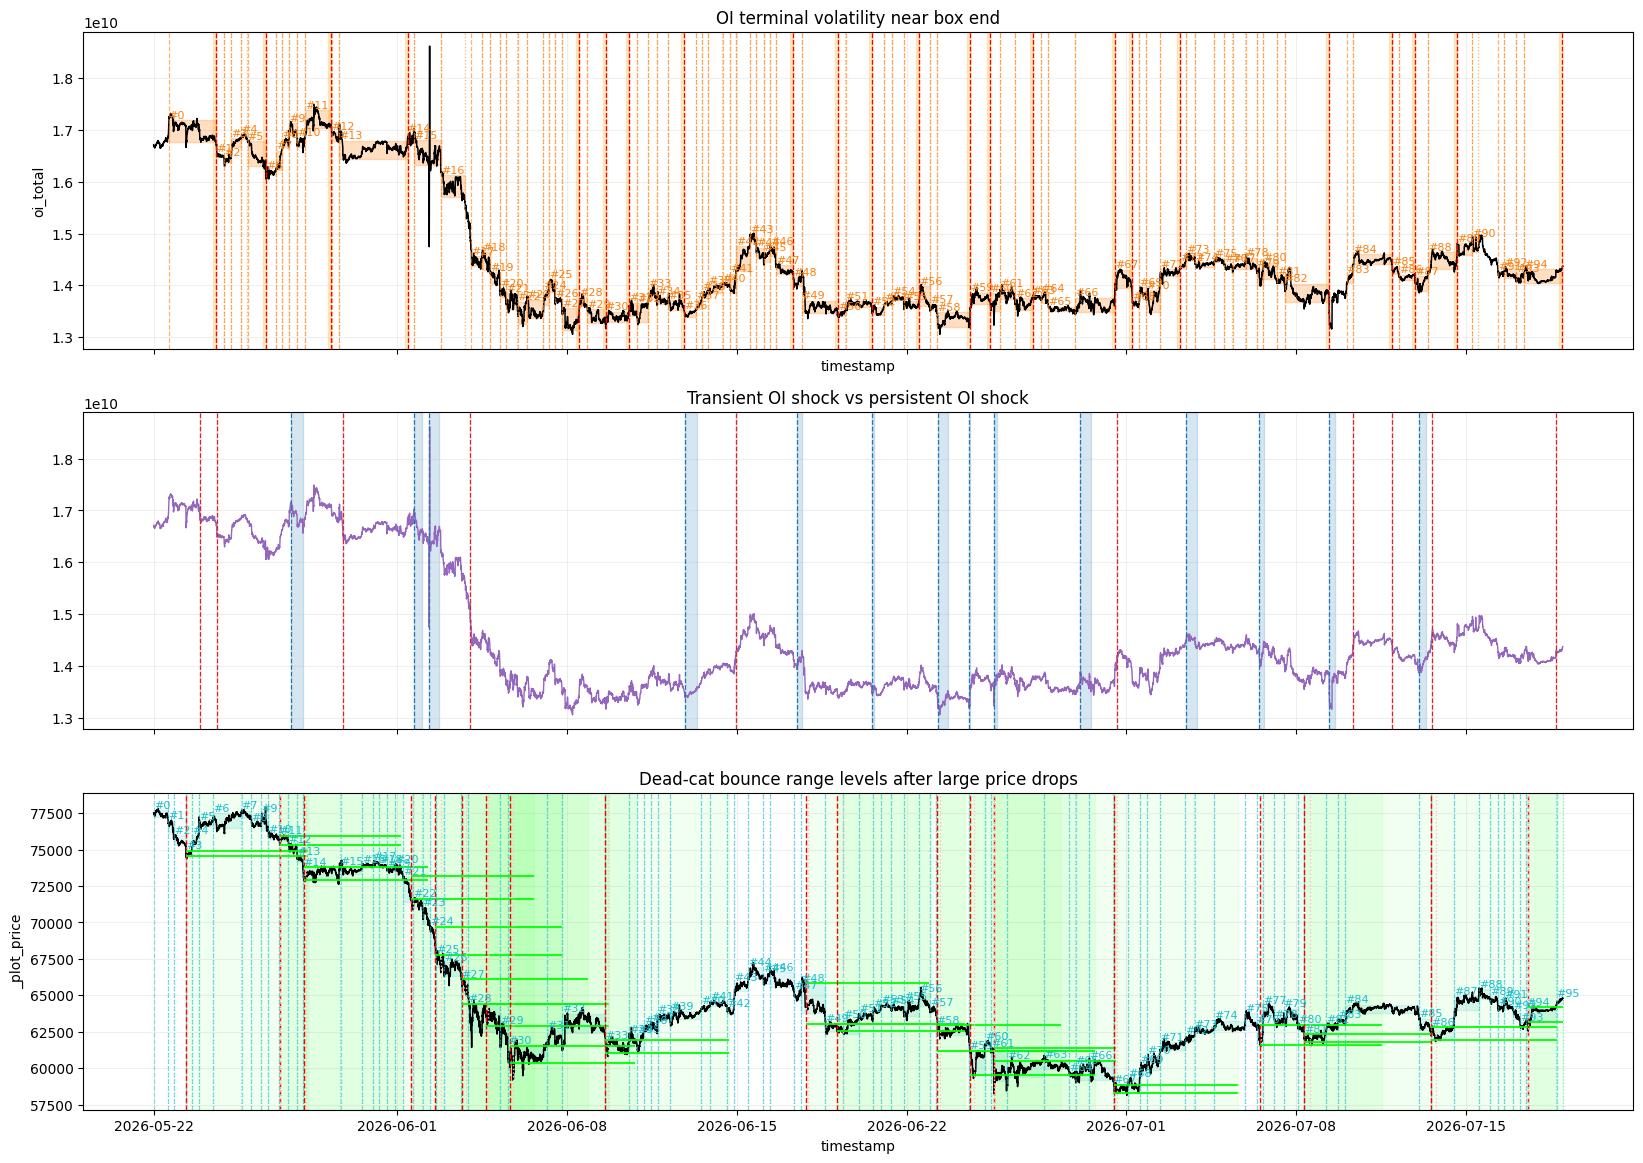

In [17]:
event_axes = plot_box_event_signals(
    price_frame=price_df,
    oi_frame=oi_df,
    price_boxes=price_boxes,
    oi_boxes=stable_oi_boxes,
    terminal_oi_volatility=terminal_oi_volatility,
    transient_oi_shocks=transient_oi_shocks,
    deadcat_bounce_ranges=deadcat_bounce_ranges,
    timestamp_col='timestamp',
    price_col='close',
    oi_col='oi_total',
)
plt.show()


## 6. Strategy Design

전략은 두 가지 모드를 가진다.

### Range Mode

Price Box 하단 근처에서는 long, 상단 근처에서는 short 후보를 만든다. 다만 OI box 필터를 켠 경우에는 stable OI box가 동시에 존재할 때만 range 진입을 허용한다.

Long 후보:

$$
Price_t \leq Lower_t + \epsilon(Upper_t - Lower_t)
$$

Short 후보:

$$
Price_t \geq Upper_t - \epsilon(Upper_t - Lower_t)
$$

### Trend Mode

Persistent OI shock과 가격 breakout이 동시에 나타나면 range mean-reversion이 아니라 trend-following 조건으로 전환한다.

리스크 관리는 다음 구조를 강제한다.

Long:

$$
SL < Entry < TP
$$

Short:

$$
TP < Entry < SL
$$

포지션 크기는 손절 거리 기반 fixed fractional risk로 계산한다.

$$
s_{bps} = \left|\frac{Entry_t - SL_t}{Entry_t}\right| \times 10,000
$$

$$
N_t = \min\left(\frac{E_t \cdot r}{s_{bps}/10,000},\ E_t \cdot \lambda_{max},\ N_{max}\right)
$$


In [18]:
def make_strategy_frame(*, use_deadcat_range: bool, config: BoxStrategyConfig) -> pd.DataFrame:
    return build_box_strategy_frame(
        price_frame=price_df,
        oi_frame=oi_df,
        price_boxes=price_boxes,
        oi_boxes=stable_oi_boxes,
        terminal_oi_volatility=terminal_oi_volatility,
        transient_oi_shocks=transient_oi_shocks,
        deadcat_bounce_ranges=deadcat_bounce_ranges if use_deadcat_range else pd.DataFrame(),
        timestamp_col='timestamp',
        price_col='close',
        high_col='high',
        low_col='low',
        oi_col='oi_total',
        config=config,
    )


def run_scenario(
    name: str,
    *,
    use_deadcat_range: bool,
    require_oi_box_for_range: bool,
    max_range_momentum_bps: float = 0.0,
    min_win_rate: float = 0.50,
    min_total_return: float = 0.0,
    min_trades: int = 5,
):
    base_config = replace(
        BASE_STRATEGY_CONFIG,
        require_oi_box_for_range=require_oi_box_for_range,
        max_range_momentum_bps=max_range_momentum_bps,
    )
    frame = make_strategy_frame(use_deadcat_range=use_deadcat_range, config=base_config)
    candidates = candidate_box_strategy_configs(
        base_config,
        entry_edge_ratios=(0.06, 0.08, 0.12, 0.18),
        bounce_confirm_bps_values=(3.0, 8.0, 15.0),
        trailing_stop_bps_values=(220.0,),
        range_stop_buffer_bps_values=(60.0, 110.0),
        risk_per_trade_values=(0.0015,),
    )
    result, report = optimize_box_strategy(
        frame,
        candidate_configs=candidates,
        timestamp_col='timestamp',
        price_col='close',
        high_col='high',
        low_col='low',
        min_win_rate=min_win_rate,
        min_total_return=min_total_return,
        min_trades=min_trades,
    )
    row = {
        'scenario': name,
        'passes_constraints': result.passes_constraints,
        'use_deadcat_range': use_deadcat_range,
        'require_oi_box_for_range': require_oi_box_for_range,
        'max_range_momentum_bps': max_range_momentum_bps,
        **result.metrics,
        'selected_config': str(result.config),
    }
    return row, result, report, frame


## 7. Backtest: Scenario Ablation

세 가지 핵심 시나리오를 비교한다.

1. `deadcat_as_range`: dead-cat rebound level을 직접 거래 range로 사용
2. `price_box_only`: Price Box만 사용
3. `price_box_plus_oi_box`: Price Box와 Stable OI Box가 동시에 있을 때만 range 진입

포트폴리오 해석상 중요한 비교는 `price_box_only`와 `price_box_plus_oi_box`다. OI 필터는 수익 기회를 무조건 늘리는 신호라기보다, 시장 상태와 맞지 않는 저품질 진입을 줄이는 필터로 해석한다.


In [19]:
scenario_specs = [
    {
        'name': 'deadcat_as_range',
        'use_deadcat_range': True,
        'require_oi_box_for_range': False,
        'max_range_momentum_bps': 0.0,
    },
    {
        'name': 'price_box_only',
        'use_deadcat_range': False,
        'require_oi_box_for_range': False,
        'max_range_momentum_bps': 0.0,
    },
    {
        'name': 'price_box_plus_oi_box',
        'use_deadcat_range': False,
        'require_oi_box_for_range': True,
        'max_range_momentum_bps': 0.0,
    },
]

scenario_rows = []
scenario_results = {}
scenario_reports = {}
scenario_frames = {}

for spec in scenario_specs:
    row, result, report, frame = run_scenario(**spec)
    scenario_rows.append(row)
    scenario_results[spec['name']] = result
    scenario_reports[spec['name']] = report
    scenario_frames[spec['name']] = frame

scenario_summary = pd.DataFrame(scenario_rows).sort_values(
    ['passes_constraints', 'total_return', 'profit_factor', 'win_rate'],
    ascending=[False, False, False, False],
).reset_index(drop=True)

result_view = scenario_summary[[
    'scenario',
    'passes_constraints',
    'total_return',
    'win_rate',
    'profit_factor',
    'max_drawdown',
    'total_trades',
]].copy()
for col in ['total_return', 'win_rate', 'max_drawdown']:
    result_view[col + '_pct'] = result_view[col] * 100.0

result_view = result_view[[
    'scenario',
    'passes_constraints',
    'total_return_pct',
    'win_rate_pct',
    'profit_factor',
    'max_drawdown_pct',
    'total_trades',
]]

display(result_view)


,scenario,passes_constraints,total_return_pct,win_rate_pct,profit_factor,max_drawdown_pct,total_trades
0,price_box_only,True,11.017486,71.559633,2.437595,-0.931195,218.0
1,price_box_plus_oi_box,True,10.439929,71.844660,2.443998,-0.874797,206.0
2,deadcat_as_range,False,-2.163969,30.303030,0.760974,-2.966452,165.0


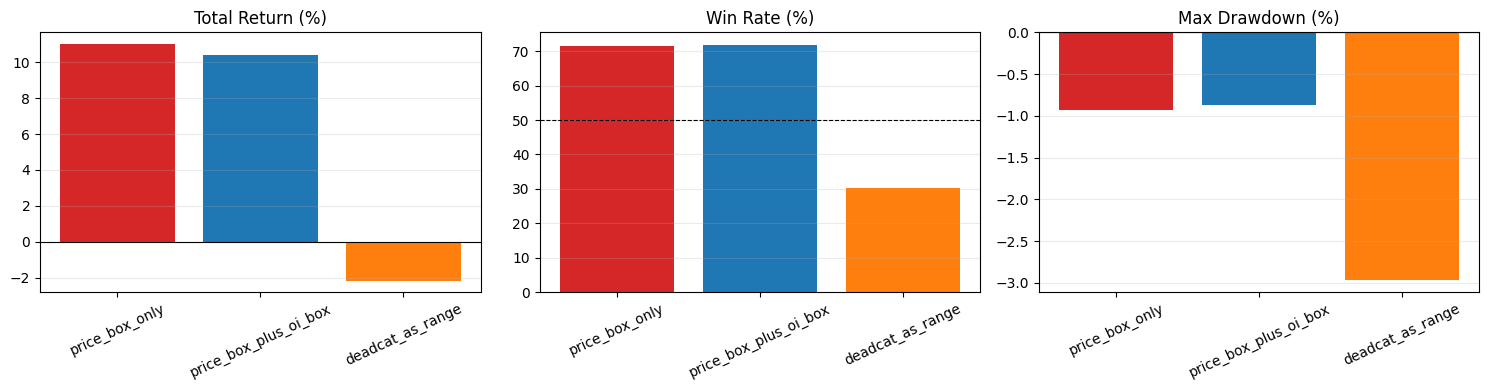

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_df = result_view.copy()

axes[0].bar(plot_df['scenario'], plot_df['total_return_pct'], color=['tab:red', 'tab:blue', 'tab:orange'])
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Total Return (%)')
axes[0].tick_params(axis='x', rotation=25)
axes[0].grid(True, axis='y', alpha=0.25)

axes[1].bar(plot_df['scenario'], plot_df['win_rate_pct'], color=['tab:red', 'tab:blue', 'tab:orange'])
axes[1].axhline(50, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title('Win Rate (%)')
axes[1].tick_params(axis='x', rotation=25)
axes[1].grid(True, axis='y', alpha=0.25)

axes[2].bar(plot_df['scenario'], plot_df['max_drawdown_pct'], color=['tab:red', 'tab:blue', 'tab:orange'])
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title('Max Drawdown (%)')
axes[2].tick_params(axis='x', rotation=25)
axes[2].grid(True, axis='y', alpha=0.25)

plt.tight_layout()
plt.show()


In [21]:
SELECTED_SCENARIO = 'price_box_plus_oi_box'
strategy_result = scenario_results[SELECTED_SCENARIO]
strategy_report = scenario_reports[SELECTED_SCENARIO]
strategy_frame = scenario_frames[SELECTED_SCENARIO]

strategy_metrics = pd.DataFrame([strategy_result.metrics])
strategy_metrics.insert(0, 'passes_constraints', strategy_result.passes_constraints)
strategy_metrics.insert(1, 'selected_scenario', SELECTED_SCENARIO)
strategy_metrics.insert(2, 'selected_config', str(strategy_result.config))

display(strategy_metrics.T.rename(columns={0: 'value'}))
display(strategy_report.head(15))
display(strategy_result.trades.tail(30))

assert strategy_result.metrics['total_trades'] >= 5
if strategy_result.passes_constraints:
    assert strategy_result.metrics['win_rate'] > 0.50
    assert strategy_result.metrics['total_return'] >= 0.0


,value
passes_constraints,True
selected_scenario,price_box_plus_oi_box
selected_config,"BoxStrategyConfig(entry_edge_ratio=0.08, exit_..."
total_return,0.104399
sharpe,12.97566
sortino,21.454474
calmar,71.577263
max_drawdown,-0.008748
win_rate,0.718447
profit_factor,2.443998


,config_id,passes_constraints,entry_edge_ratio,exit_mid_ratio,breakout_buffer_bps,momentum_bars,min_trend_momentum_bps,bounce_bars,bounce_confirm_bps,trend_activation_bars,trend_exit_bps,trailing_stop_bps,range_stop_buffer_bps,max_holding_bars,min_stop_bps,max_stop_bps,risk_per_trade,max_leverage,max_notional,require_oi_box_for_range,max_range_momentum_bps,fee_bps,slippage_bps,spread_bps,allow_short,total_return,sharpe,sortino,calmar,max_drawdown,win_rate,profit_factor,avg_trade_pnl,avg_win_loss_ratio,total_trades,max_consecutive_losses,max_consecutive_wins
0,6,True,0.08,0.5,20.0,12,12.0,3,3.0,144,4.0,220.0,60.0,288,60.0,320.0,0.0015,0.7,0.0,True,0.0,4.0,2.0,1.0,True,0.104399,12.975660,21.454474,71.577263,-0.008748,0.718447,2.443998,5.067927,0.957783,206.0,3.0,16.0
1,14,True,0.12,0.5,20.0,12,12.0,3,8.0,144,4.0,220.0,60.0,288,60.0,320.0,0.0015,0.7,0.0,True,0.0,4.0,2.0,1.0,True,0.099418,12.571393,20.801038,82.300647,-0.007262,0.732673,2.398471,4.921671,0.875118,202.0,4.0,11.0
2,8,True,0.08,0.5,20.0,12,12.0,3,8.0,144,4.0,220.0,60.0,288,60.0,320.0,0.0015,0.7,0.0,True,0.0,4.0,2.0,1.0,True,0.098543,13.018814,21.790444,130.388107,-0.004545,0.724551,2.657117,5.900774,1.010144,167.0,3.0,14.0
3,12,True,0.12,0.5,20.0,12,12.0,3,3.0,144,4.0,220.0,60.0,288,60.0,320.0,0.0015,0.7,0.0,True,0.0,4.0,2.0,1.0,True,0.097158,11.397607,18.428936,68.233713,-0.008572,0.717647,2.083162,3.810110,0.819605,255.0,4.0,13.0
4,0,True,0.06,0.5,20.0,12,12.0,3,3.0,144,4.0,220.0,60.0,288,60.0,320.0,0.0015,0.7,0.0,True,0.0,4.0,2.0,1.0,True,0.096400,12.490981,20.494423,123.153156,-0.004712,0.697802,2.430984,5.296694,1.052788,182.0,3.0,11.0
5,18,True,0.18,0.5,20.0,12,12.0,3,3.0,144,4.0,220.0,60.0,288,60.0,320.0,0.0015,0.7,0.0,True,0.0,4.0,2.0,1.0,True,0.095860,10.963455,17.790315,67.428871,-0.008565,0.739726,2.003231,3.282888,0.704841,292.0,4.0,14.0
6,16,True,0.12,0.5,20.0,12,12.0,3,15.0,144,4.0,220.0,60.0,288,60.0,320.0,0.0015,0.7,0.0,True,0.0,4.0,2.0,1.0,True,0.094557,13.404796,22.830264,129.462702,-0.004399,0.741722,2.921739,6.262050,1.017391,151.0,3.0,12.0
7,20,True,0.18,0.5,20.0,12,12.0,3,8.0,144,4.0,220.0,60.0,288,60.0,320.0,0.0015,0.7,0.0,True,0.0,4.0,2.0,1.0,True,0.094124,11.411720,18.649206,69.435021,-0.008172,0.740891,2.134223,3.810679,0.746395,247.0,4.0,12.0
8,2,True,0.06,0.5,20.0,12,12.0,3,8.0,144,4.0,220.0,60.0,288,60.0,320.0,0.0015,0.7,0.0,True,0.0,4.0,2.0,1.0,True,0.093907,13.010086,21.967700,124.510972,-0.004545,0.718121,2.755496,6.302455,1.081597,149.0,3.0,13.0
9,9,True,0.08,0.5,20.0,12,12.0,3,8.0,144,4.0,220.0,110.0,288,60.0,320.0,0.0015,0.7,0.0,True,0.0,4.0,2.0,1.0,True,0.088124,14.531976,28.157238,143.466211,-0.003710,0.796178,3.716965,5.613019,0.951543,157.0,5.0,21.0


,entry_time,exit_time,direction,mode,entry_reason,exit_reason,entry_price,exit_price,stop_loss,take_profit,notional,gross_pnl,cost,pnl,bars_held
176,2026-07-08 15:00:00,2026-07-08 16:40:00,1,range,range_lower_edge_bounce,range_take_profit,61776.2,62047.335000,61404.392146,62047.3350,2718.655056,11.932144,3.534252,8.397893,20
177,2026-07-09 01:20:00,2026-07-09 01:40:00,-1,range,range_upper_edge_reject,range_take_profit,62418.1,62047.335000,62693.545366,62047.3350,2745.706969,16.309565,3.569419,12.740146,4
178,2026-07-09 03:15:00,2026-07-09 04:05:00,1,range,range_lower_edge_bounce,range_take_profit,61755.0,62047.335000,61404.392146,62047.3350,2748.892005,13.012669,3.573560,9.439109,10
179,2026-07-09 05:15:00,2026-07-09 06:00:00,-1,range,range_upper_edge_reject,stop_loss,62383.1,62693.545366,62693.545366,62047.3350,2751.251782,-13.691422,3.576627,-17.268050,9
180,2026-07-09 06:00:00,2026-07-09 06:05:00,1,range,range_lower_edge_bounce,risk_off_exit,62621.3,62493.500000,62231.964738,62823.2950,2634.446415,-5.376481,3.424780,-8.801262,1
181,2026-07-10 02:20:00,2026-07-10 04:35:00,1,range,range_lower_edge_bounce,range_take_profit,63806.3,64067.260000,63391.437110,64067.2600,2516.387933,10.291720,3.271304,7.020416,27
182,2026-07-10 09:50:00,2026-07-10 14:15:00,-1,range,range_upper_edge_reject,range_take_profit,64386.9,64067.260000,64746.601030,64067.2600,2746.489558,13.634574,3.570436,10.064137,53
183,2026-07-10 20:30:00,2026-07-10 21:35:00,1,range,range_lower_edge_bounce,range_take_profit,63810.1,64067.260000,63391.437110,64067.2600,2497.428162,10.064843,3.246657,6.818186,13
184,2026-07-11 14:45:00,2026-07-11 15:35:00,-1,range,range_upper_edge_reject,range_take_profit,64351.4,64067.260000,64746.601030,64067.2600,2687.422879,11.866165,3.493650,8.372515,10
185,2026-07-12 00:20:00,2026-07-12 01:40:00,1,range,range_lower_edge_bounce,range_take_profit,63814.4,64067.260000,63391.437110,64067.2600,2475.453420,9.808807,3.218089,6.590718,16


## 8. Backtest Safety Check

백테스트 성과가 좋아 보여도, 진입·손절·목표가 구조가 잘못되면 성과가 왜곡될 수 있다. 따라서 모든 체결에 대해 다음 구조를 검증한다.

Long:

$$
SL < Entry < TP
$$

Short:

$$
TP < Entry < SL
$$

이 조건을 만족하지 않는 거래는 시뮬레이터에서 진입하지 않아야 한다.


In [22]:
trades = strategy_result.trades.copy()
if trades.empty:
    invalid_geometry = pd.DataFrame()
else:
    long_invalid = (trades['direction'] > 0) & ~(
        (trades['stop_loss'] < trades['entry_price'])
        & (trades['entry_price'] < trades['take_profit'])
    )
    short_invalid = (trades['direction'] < 0) & ~(
        (trades['take_profit'] < trades['entry_price'])
        & (trades['entry_price'] < trades['stop_loss'])
    )
    invalid_geometry = trades[long_invalid | short_invalid]

display(invalid_geometry)
assert invalid_geometry.empty


,entry_time,exit_time,direction,mode,entry_reason,exit_reason,entry_price,exit_price,stop_loss,take_profit,notional,gross_pnl,cost,pnl,bars_held


## 9. Strategy Result Visualization

최종 선택 전략의 equity curve, 가격 박스 진입 지점, 거래별 PnL을 함께 확인한다.


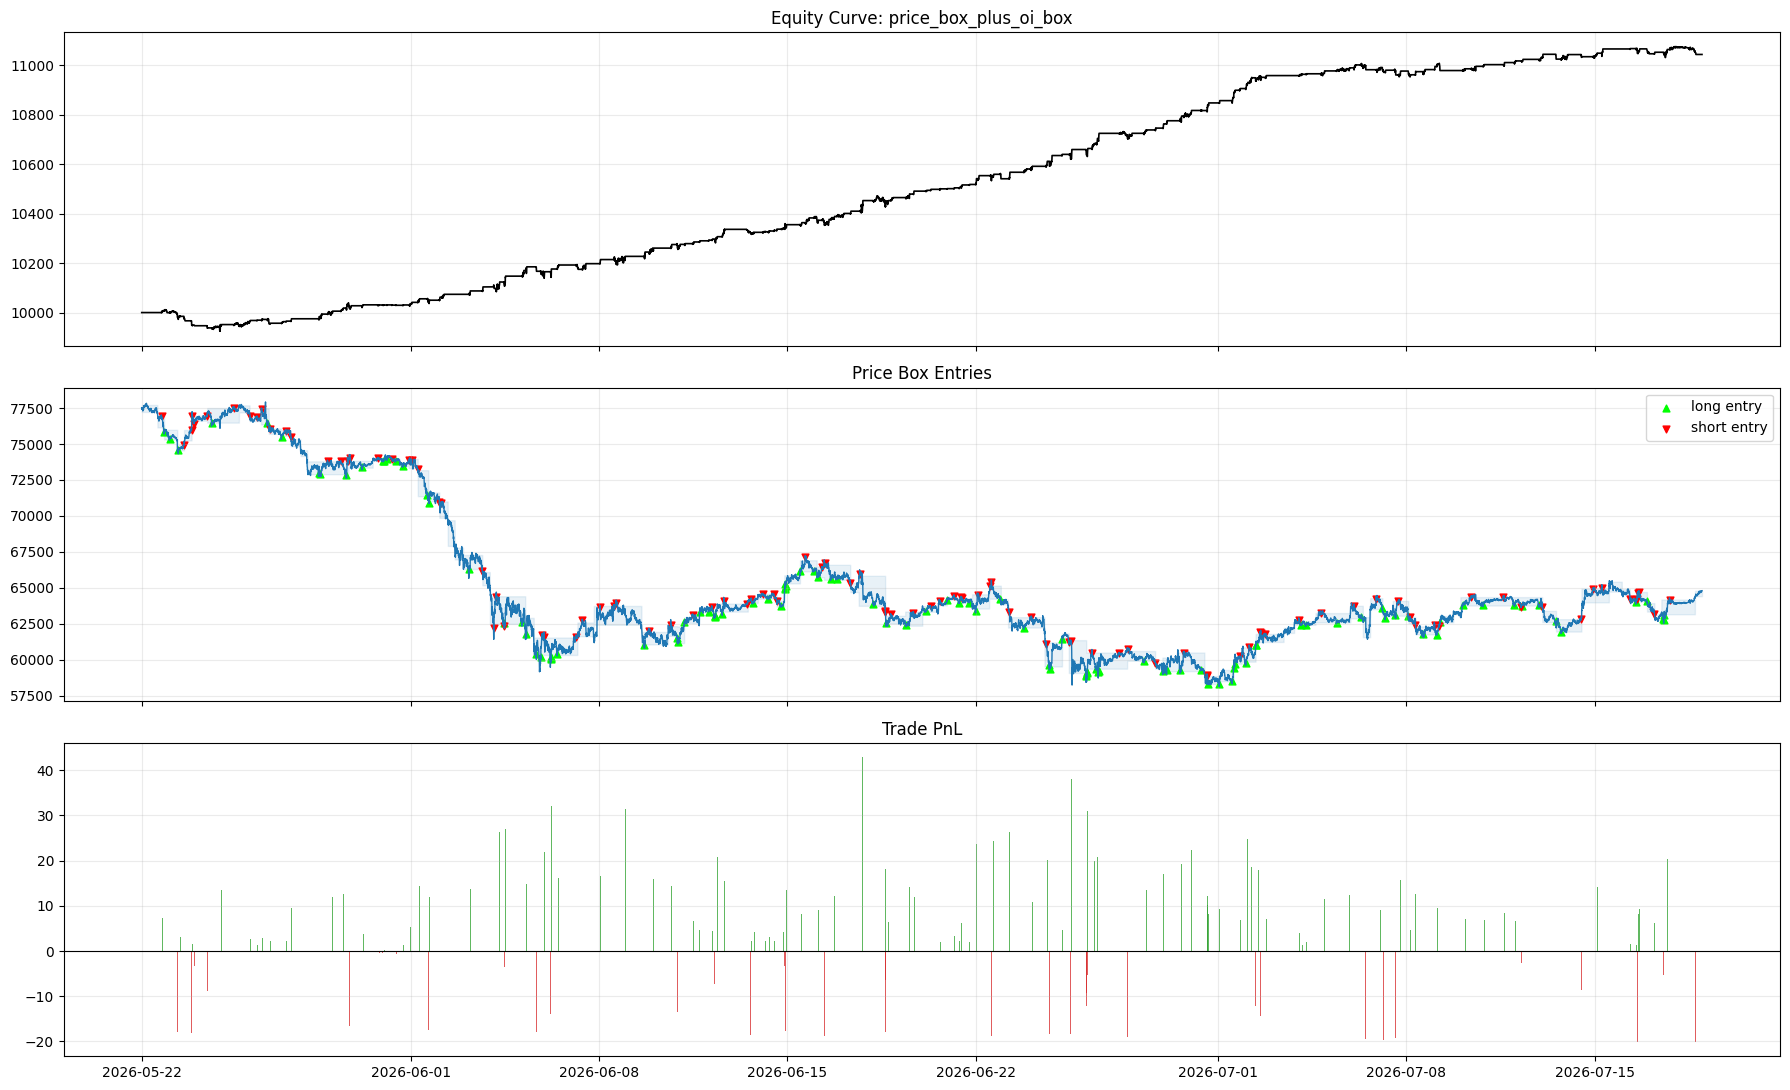

In [23]:
fig, axes = plt.subplots(3, 1, figsize=(18, 11), sharex=True)

axes[0].plot(strategy_result.equity_curve['timestamp'], strategy_result.equity_curve['equity'], color='black', linewidth=1.2)
axes[0].set_title(f'Equity Curve: {SELECTED_SCENARIO}')
axes[0].grid(True, alpha=0.25)

axes[1].plot(strategy_frame['timestamp'], strategy_frame['close'], color='tab:blue', linewidth=1.0)
axes[1].fill_between(
    strategy_frame['timestamp'],
    strategy_frame['active_range_low'],
    strategy_frame['active_range_high'],
    color='tab:blue',
    alpha=0.10,
)
if not strategy_result.trades.empty:
    long_trades = strategy_result.trades[strategy_result.trades['direction'] > 0]
    short_trades = strategy_result.trades[strategy_result.trades['direction'] < 0]
    axes[1].scatter(long_trades['entry_time'], long_trades['entry_price'], marker='^', color='lime', s=24, label='long entry')
    axes[1].scatter(short_trades['entry_time'], short_trades['entry_price'], marker='v', color='red', s=24, label='short entry')
    axes[1].legend(loc='best')
axes[1].set_title('Price Box Entries')
axes[1].grid(True, alpha=0.25)

if not strategy_result.trades.empty:
    colors = strategy_result.trades['pnl'].map(lambda x: 'tab:green' if x >= 0 else 'tab:red')
    axes[2].bar(strategy_result.trades['exit_time'], strategy_result.trades['pnl'], width=0.025, color=colors, alpha=0.75)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title('Trade PnL')
axes[2].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


## 10. Capital Simulation

초기 시드를 10,000,000원으로 두고 단순 복리 기준 최종 금액을 계산한다. 이 계산은 실제 미래 수익 보장이 아니라, 백테스트 기간의 전략 수익률을 자본 기준으로 환산한 것이다.


In [24]:
INITIAL_CAPITAL = 10_000_000

capital_rows = []
for row in result_view.itertuples(index=False):
    total_return = float(row.total_return_pct) / 100.0
    final_capital = INITIAL_CAPITAL * (1.0 + total_return)
    capital_rows.append({
        'scenario': row.scenario,
        'initial_capital': INITIAL_CAPITAL,
        'total_return_pct': row.total_return_pct,
        'final_capital': final_capital,
        'pnl': final_capital - INITIAL_CAPITAL,
    })

capital_summary = pd.DataFrame(capital_rows)
display(capital_summary.style.format({
    'initial_capital': '{:,.0f}',
    'total_return_pct': '{:.4f}%',
    'final_capital': '{:,.0f}',
    'pnl': '{:,.0f}',
}))


,scenario,initial_capital,total_return_pct,final_capital,pnl
0,price_box_only,"10,000,000",11.0175%,"11,101,749","1,101,749"
1,price_box_plus_oi_box,"10,000,000",10.4399%,"11,043,993","1,043,993"
2,deadcat_as_range,"10,000,000",-2.1640%,"9,783,603","-216,397"


## 11. Interpretation & Limitations

### Interpretation

- `deadcat_as_range`는 진단용 레벨로는 의미가 있지만, 직접 진입 range로 사용하면 오래된 레벨이 현재 price box를 덮어써 성과를 훼손할 수 있다.
- `price_box_only`는 거래 수와 수익 기회가 더 많지만, 시장 상태와 맞지 않는 진입도 포함될 수 있다.
- `price_box_plus_oi_box`는 거래 수를 줄이더라도, OI가 안정적인 구조를 함께 확인하여 저품질 진입을 줄이는 필터로 해석할 수 있다.

### Limitations

- 검증 기간이 약 두 달 수준으로 짧다.
- BTCUSDT 중심 결과이므로 다른 자산과 다른 시장 국면에서 재검증이 필요하다.
- 체결 비용은 보수적으로 넣었지만, 실제 주문장 깊이와 시장 충격까지 완전히 반영하지는 못한다.
- 향후에는 더 긴 과거 데이터, walk-forward 검증, 실시간 paper trading, 주문 체결 로그 기반 slippage 추정이 필요하다.
